In [ ]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import Matern


In [ ]:
def Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix=None):
    '''
    theta: vector of 3 [Matern_param, coef_distmat, coef_topomat]. The coefs are applied to the matricies to form the ditance matrix used as input in the Matern kernel to form the covariance.
    sub_locs: a set of subsets of location indexes with the same number of locs in each.
    days_nb: how many days to include on the subsample.
    sim_nb: number of simulation draws to compare with original data in the score.
    observations_x: x, observed rainfall transformed to a Gaussian normal scale. This is the data that we try to emulate.
    censor_levels_di: d, probability of no rain (1-p) transformed to a normal scale. These are used to censor simulations (x') when comparingt to x.
    '''
    # Subsample locations. Choose a random subset the list of subsets - sub_locs.
    locs = sub_locs[np.random.choice(range(len(sub_locs)))] 
    locs_nb = len(locs)
    # Subsample days.
    days = np.random.choice(range(len(observations_x)),size=days_nb,replace=False)

    # Select relevant subsamples of data.
    x = observations_x[days,:][:,locs]
    d = censor_levels_di[days,:][:,locs]
    
    # Create covariance matrix.
    if np.sum(topo_matrix==None):
        cov_mat = np.nan_to_num(Matern(length_scale=theta,nu=3.5).__call__(dist_matrix[locs,:][:,locs]))
    else:
        cov_mat = np.nan_to_num(Matern(length_scale=theta[0],nu=3.5).__call__(theta[1]*dist_mat[locs,:][:,locs]+((1-theta[1])/70)*topo_dist[locs,:][:,locs]))

    # Draw samples from the multivariate nromal with appropriate covariance.
    simulations = scs.multivariate_normal(mean=np.zeros(locs_nb),cov=cov_mat,allow_singular=True).rvs(size=sim_nb)
    
    # Censor simulated values and format them into [[sim0-day0,sim0-day1,...,sim0-dayn] ,..., [sim_m-day0,sim_m-day1,...,sim_m-dayn]]. Gives sim_nb*days_nb=m*n vectors of len=locs_nb. 
    censored_sims = np.maximum(np.repeat(simulations,days_nb,axis=0),np.tile(d,(sim_nb,1)))

    # ||x' - x' ||_2 component of energy score
    sims_by_day = [censored_sims[0+k::days_nb] for k in range(days_nb)] # regroup to get [[sim(1,day1), sim(2,day1),...,sim(m,day1)],...,[sim(1,dayn), sim(2,dayn),...,sim(m,dayn)]].
    
    sim_L2_diff = 0
    
    for sim_day_i in sims_by_day: # don't know how to make it more efficient... maybe can parallelize to compute complete score
        
        # ||x' - x' ||_2 component of energy score
            # OLD: einsum from Lorenzos code on each sim_day_i was 9x slower then doing pdist on each sim_day_i. Both give the same answer
        '''
        # matrix of all combinations over i of [vector_i-vector_1, ... , vector_i-vector_n]
        temp_diff_combinations_matrix = sim_day_i.reshape(1,sim_nb,locs_nb)-sim_day_i.reshape(sim_nb,1,locs_nb) 
        # einsum creates a matrix of sum of squares, then take sqrt to get L2.
        sim_L2_diff+=0.5*np.sum(np.sqrt(np.einsum('ijk, ijk -> ij',temp_diff_combinations_matrix,temp_diff_combinations_matrix))) 
        '''
            # New: pdist takes the offdiagonal of an L2 distance matrix, only counting once each combination of Y,Y'.
        sim_L2_diff+= 2 * np.sum(np.power(pdist(sim_day_i),beta))

    # Add both parts of Energy.
    Energy = 2 * np.mean(np.power(np.linalg.norm(censored_sims - np.tile(x,(sim_nb,1)),axis=1),beta)) - sim_L2_diff/(days_nb*sim_nb*(sim_nb-1))
    
    
    #path_.append([theta,Energy])
    print([theta,Energy])

    return Energy

path_avg = []

def Spatial_Energy_Score_sublocs_averaged(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix,avg_nb):
    avg_SR = 0

    for s in range(avg_nb):
        avg_SR+= Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix)

    path_avg.append(avg_SR/avg_nb)
    
    return avg_SR/avg_nb

# Minimal examples

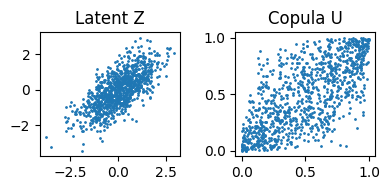

In [6]:
# generate Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=1)
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=1)
axes[1].set_title('Copula U')

plt.tight_layout()
plt.show()